# Simulación Dinámica de la Órbita de un Cohete: El Problema de los Tres Cuerpos Restringido

**Autor:** Alberto Jiménez Cañadillas

En este trabajo he desarrollado una simulación numérica para estudiar la trayectoria de un cohete en el sistema Tierra-Luna. Al tratarse de un problema sin solución analítica general (el clásico Problema de los Tres Cuerpos), recurrimos a la aproximación restringida circular, donde la masa del cohete es despreciable frente a los dos cuerpos celestes.

Para el motor de la simulación, he programado el código en **C++** (archivo `cohete.cpp`), implementando el algoritmo de **Runge-Kutta de 4º orden (RK4)** para integrar las ecuaciones diferenciales del movimiento. Para el análisis de los resultados, la verificación de la conservación de la energía mediante la Integral de Jacobi y la generación de gráficos interactivos, he utilizado **Python** (Matplotlib y NumPy) integrado en este entorno de trabajo. 

**Importante:**  Para optimizar el desarrollo, la depuración y la revisión sintáctica del código en C++ y Python, se integraron herramientas de inteligencia artificial a modo de copiloto, empleando principalmente Gemini y Copilot, y, de manera puntual, Claude, empleándolas así como asistentes de programación. Además, los códigos en C++ y en python se ejecutaron íntegramente de forma local, utilizando un entorno de desarrollo basado en una máquina virtual con el sistema operativo Linux (en su distribución Ubuntu / Linux Mint). Las simulaciones pesadas y el barrido continuo de temperaturas se compilaron en `C++` mediante el compilador `g++`, aplicando el flag de optimización de alto rendimiento **`-O3`** (`g++ -O3 main.cpp`) para maximizar la velocidad de procesamiento de los bucles y el uso de la memoria caché. El post-procesado de datos, el volcado gráfico de los observables y el renderizado de los ficheros de animación se gestionaron desde entornos virtuales de Python (`venv`) en la misma máquina virtual. En cuanto al hardware físico que soportó la virtualización, las simulaciones se corrieron en un ordenador portátil equipado con un procesador de alto rendimiento **11th Gen Intel(R) Core(TM) i5-11400H @ 2.70GHz**, contando con 16.0 GB de memoria RAM física y utilizando la arquitectura de gráficos integrados **Intel(R) UHD Graphics** para el soporte visual básico de la interfaz de desarrollo.

## 1. Visualización de Trayectorias y Órbitas

A continuación, se presentan los resultados visuales extraídos de las simulaciones dinámicas para diferentes configuraciones de condiciones iniciales (ángulos de inyección y velocidades).

*Nota: Para reproducir los archivos de vídeo localmente dentro de este cuaderno, los archivos `.mp4` generados deben encontrarse en el mismo directorio de ejecución.*

--- Simulación: Caso 0 ---


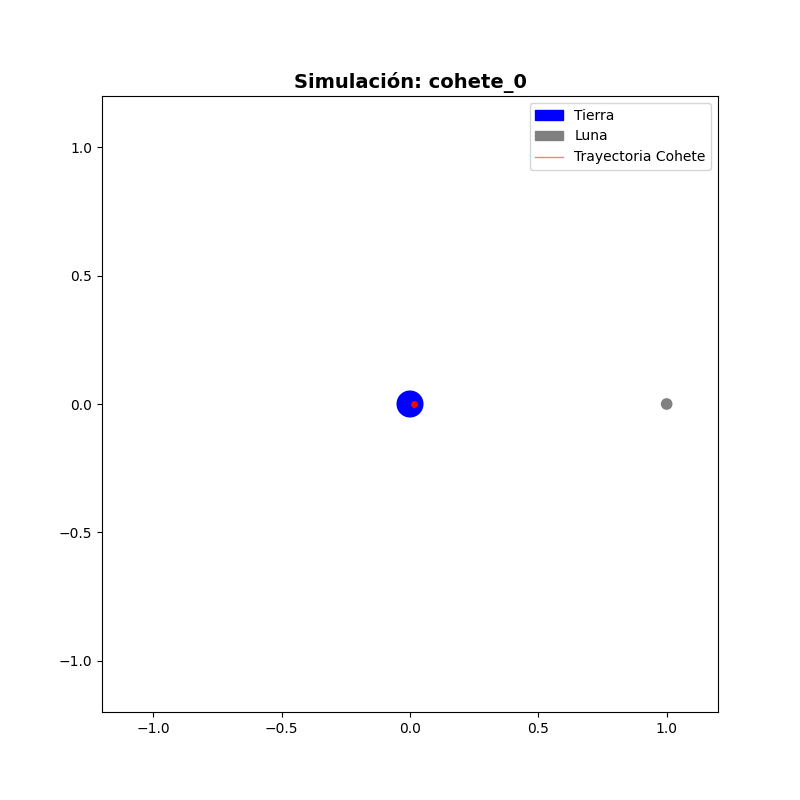

--- Simulación: Caso 1 ---


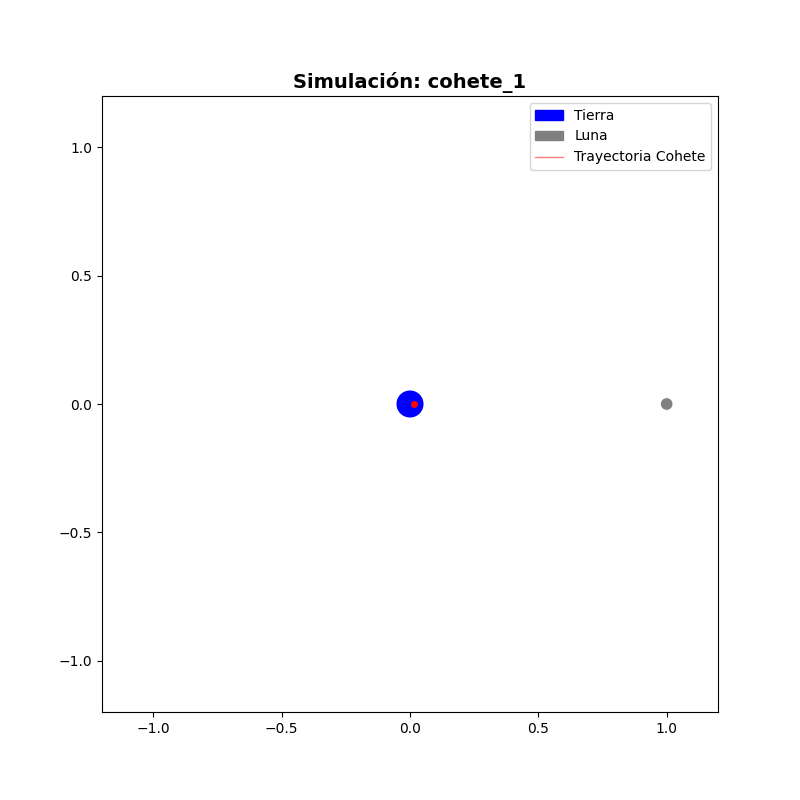

--- Simulación: Caso 2 ---


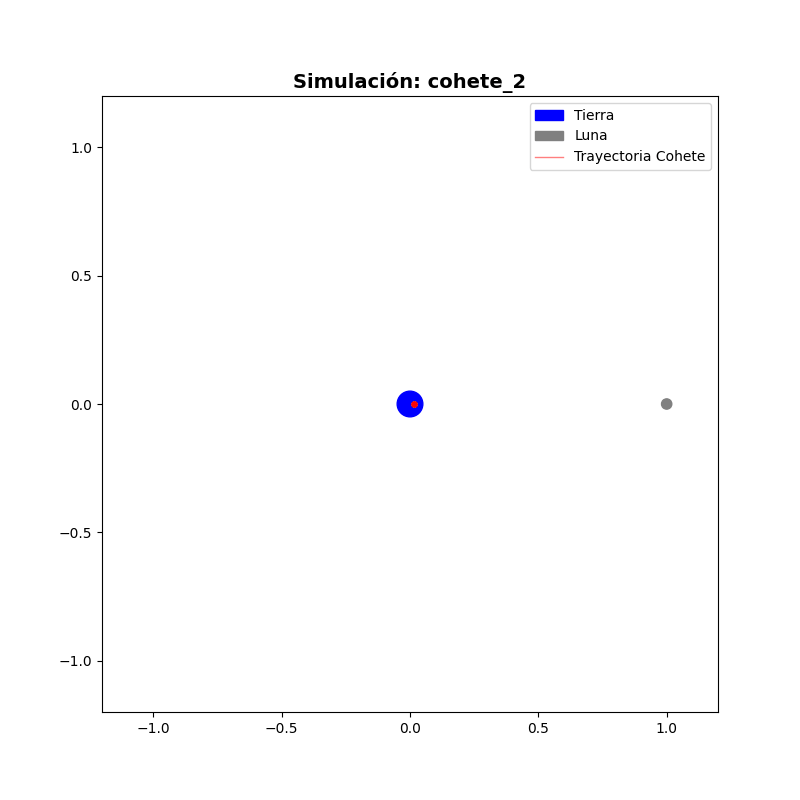

--- Simulación: Caso 3 ---


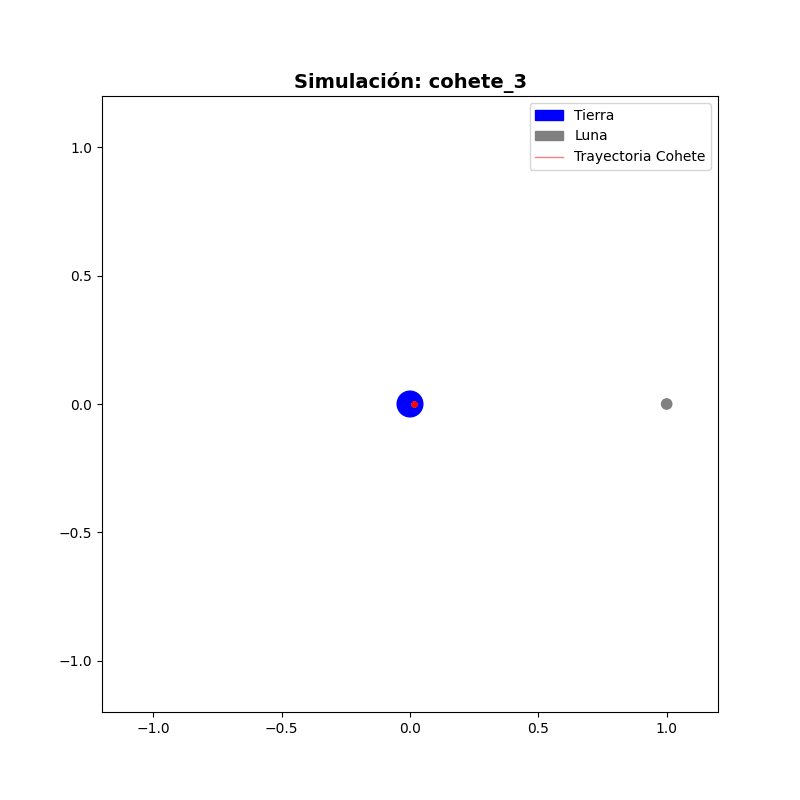

In [1]:
import os
from IPython.display import Image, display

for i in range(4):
    archivo_gif = f"cohete_{i}.gif"
    if os.path.exists(archivo_gif):
        print(f"--- Simulación: Caso {i} ---")
        display(Image(filename=archivo_gif, width=700))
    else:
        print(f"[Aviso] No se encontró {archivo_gif}")

## Análisis y Discusión de los Resultados

A continuación, se detallan las condiciones iniciales empleadas en cada una de las simulaciones del Problema Restringido de los Tres Cuerpos (Tierra-Luna-Cohete) y se analiza el comportamiento físico observado en las trayectorias resultantes.

### 1. Cuadro Comparativo de Condiciones Iniciales

| Caso | Factor de Velocidad ($v_0$) | Ángulo de Lanzamiento ($\theta$) | Comportamiento Observado |
| :---: | :---: | :---: | :--- |
| **Caso 0** | 0.9910 | 20.0° | Órbita elíptica cerrada / Retorno a la Tierra. |
| **Caso 1** | 0.9916 | 45.0° | Escape parabólico/hiperbólico sin interacción lunar. |
| **Caso 2** | 0.9922 | 55.0° | Trayectoria balística con aproximación lejana. |
| **Caso 3** | 0.9930 | 60.0° | **Asistencia Gravitatoria (Efecto Honda).** |

---

### 2. Interpretación Física de las Trayectorias

#### Caso 0: Régimen Suborbital / Órbita Cerrada
En este escenario, el cohete se lanza con una velocidad inicial de 0.9910 veces la velocidad de escape terrestre y un ángulo de 20.0°. Al ser inferior a la velocidad de escape del sistema Tierra-Luna, la energía cinética inicial no es suficiente para vencer el pozo de potencial gravitatorio terrestre de forma permanente ni para aproximarse a la órbita lunar. Físicamente, el cohete describe una elipse kepleriana clásica dominada casi en su totalidad por la masa de la Tierra, alcanzando un apogeo máximo antes de volver a caer hacia el planeta.

#### Caso 1 y Caso 2: Escape y Trayectorias No Acopladas
Al incrementar el factor de velocidad (a 0.9916 y 0.9922) y el ángulo (a 45.0° y 55.0°), el cohete adquiere la energía necesaria para escapar de la atracción inmediata de la Tierra. Sin embargo, debido a que el ángulo de lanzamiento $\theta$ no está alineado con la posición dinámica de la Luna en su órbita, el cohete pasa a una distancia considerable de esta. Como la fuerza gravitatoria disminuye de forma inversamente proporcional al cuadrado de la distancia ($1/d^2$), el efecto de la masa lunar sobre el cohete en estos casos es insignificante. La trayectoria se asemeja a una línea hiperbólica suave en el sistema de referencia rotatorio.

#### Caso 3: Asistencia Gravitatoria (Efecto Honda)
Este es el caso de mayor interés físico, donde se observa claramente cómo **la trayectoria del cohete se ve drásticamente afectada por el campo gravitatorio de la Luna**. 

Al ajustar con precisión tanto la velocidad inicial (0.9930) como el ángulo de apuntamiento $\theta$ (60.0°), el cohete interseca la esfera de influencia de la Luna en el instante exacto en que esta se encuentra en esa región del espacio. Físicamente ocurren los siguientes fenómenos:

1. **Desviación de la Trayectoria:** La intensa atracción gravitatoria del satélite curva fuertemente la trayectoria del cohete, provocando un cambio radical en su vector dirección (un giro cerrado alrededor de la Luna).
2. **Transferencia de Energía:** Aunque en el sistema de referencia rotatorio (sinódico) la energía pseudopotencial se conserva a través de la **Integral de Jacobi ($H'$)**, si observáramos el fenómeno desde un sistema inercial (fijo), la Luna está en movimiento. El cohete "saca" energía de la energía orbital de la Luna, lo que se traduce en una aceleración neta (o deceleración, según el ángulo de entrada) respecto a la Tierra tras el encuentro.

Este caso demuestra experimentalmente cómo el problema de los tres cuerpos rompe las órbitas keplerianas cónicas simples, dando lugar a transferencias de momento lineal y angular que son la base de la navegación espacial interplanetaria moderna.

## 2. Análisis de Estabilidad Energética (Integral de Jacobi)

Un aspecto fundamental para validar la precisión del integrador numérico **RK4** es comprobar la conservación de la **Integral de Jacobi ($H'$)**, la cual debe permanecer estrictamente constante a lo largo del tiempo en el sistema de referencia rotatorio.


**Justificación Teórica:**
En el Problema Restringido de los Tres Cuerpos, el sistema es dependiente del tiempo cuando se analiza desde un sistema de referencia inercial (fijo). Esto ocurre debido al movimiento orbital de los cuerpos masivos (la Tierra y la Luna). Como el Hamiltoniano clásico $H$ (que representa la energía total del cohete) depende explícitamente del tiempo, **la energía total no se conserva** a lo largo del vuelo ($\frac{dH}{dt} \neq 0$).

Sin embargo, si trasladamos las ecuaciones de movimiento a un **sistema de referencia rotatorio** (sinódico) que gire solidariamente con la Luna a su velocidad angular constante $\omega$, el tiempo desaparece implícitamente del potencial gravitatorio. En este sistema existe una constante de movimiento conocida como la **Integral de Jacobi ($H'$)**, definida matemáticamente como:

$$H' = H - \omega p_\phi$$

Donde:
* $H$ es la energía total clásica (cinética + potencial).
* $\omega$ es la velocidad angular de la Luna.
* $p_\phi$ es el momento angular conjugado del cohete.

Monitorear el valor de $H'$ a lo largo del tiempo es la herramienta definitiva para evaluar la **precisión numérica** de nuestro algoritmo de integración Runge-Kutta de 4º orden (RK4). Si el método es preciso, la variación de $H'$ respecto a su valor inicial ($H' - H'_0$) debería mantenerse en valores extremadamente cercanos a cero.

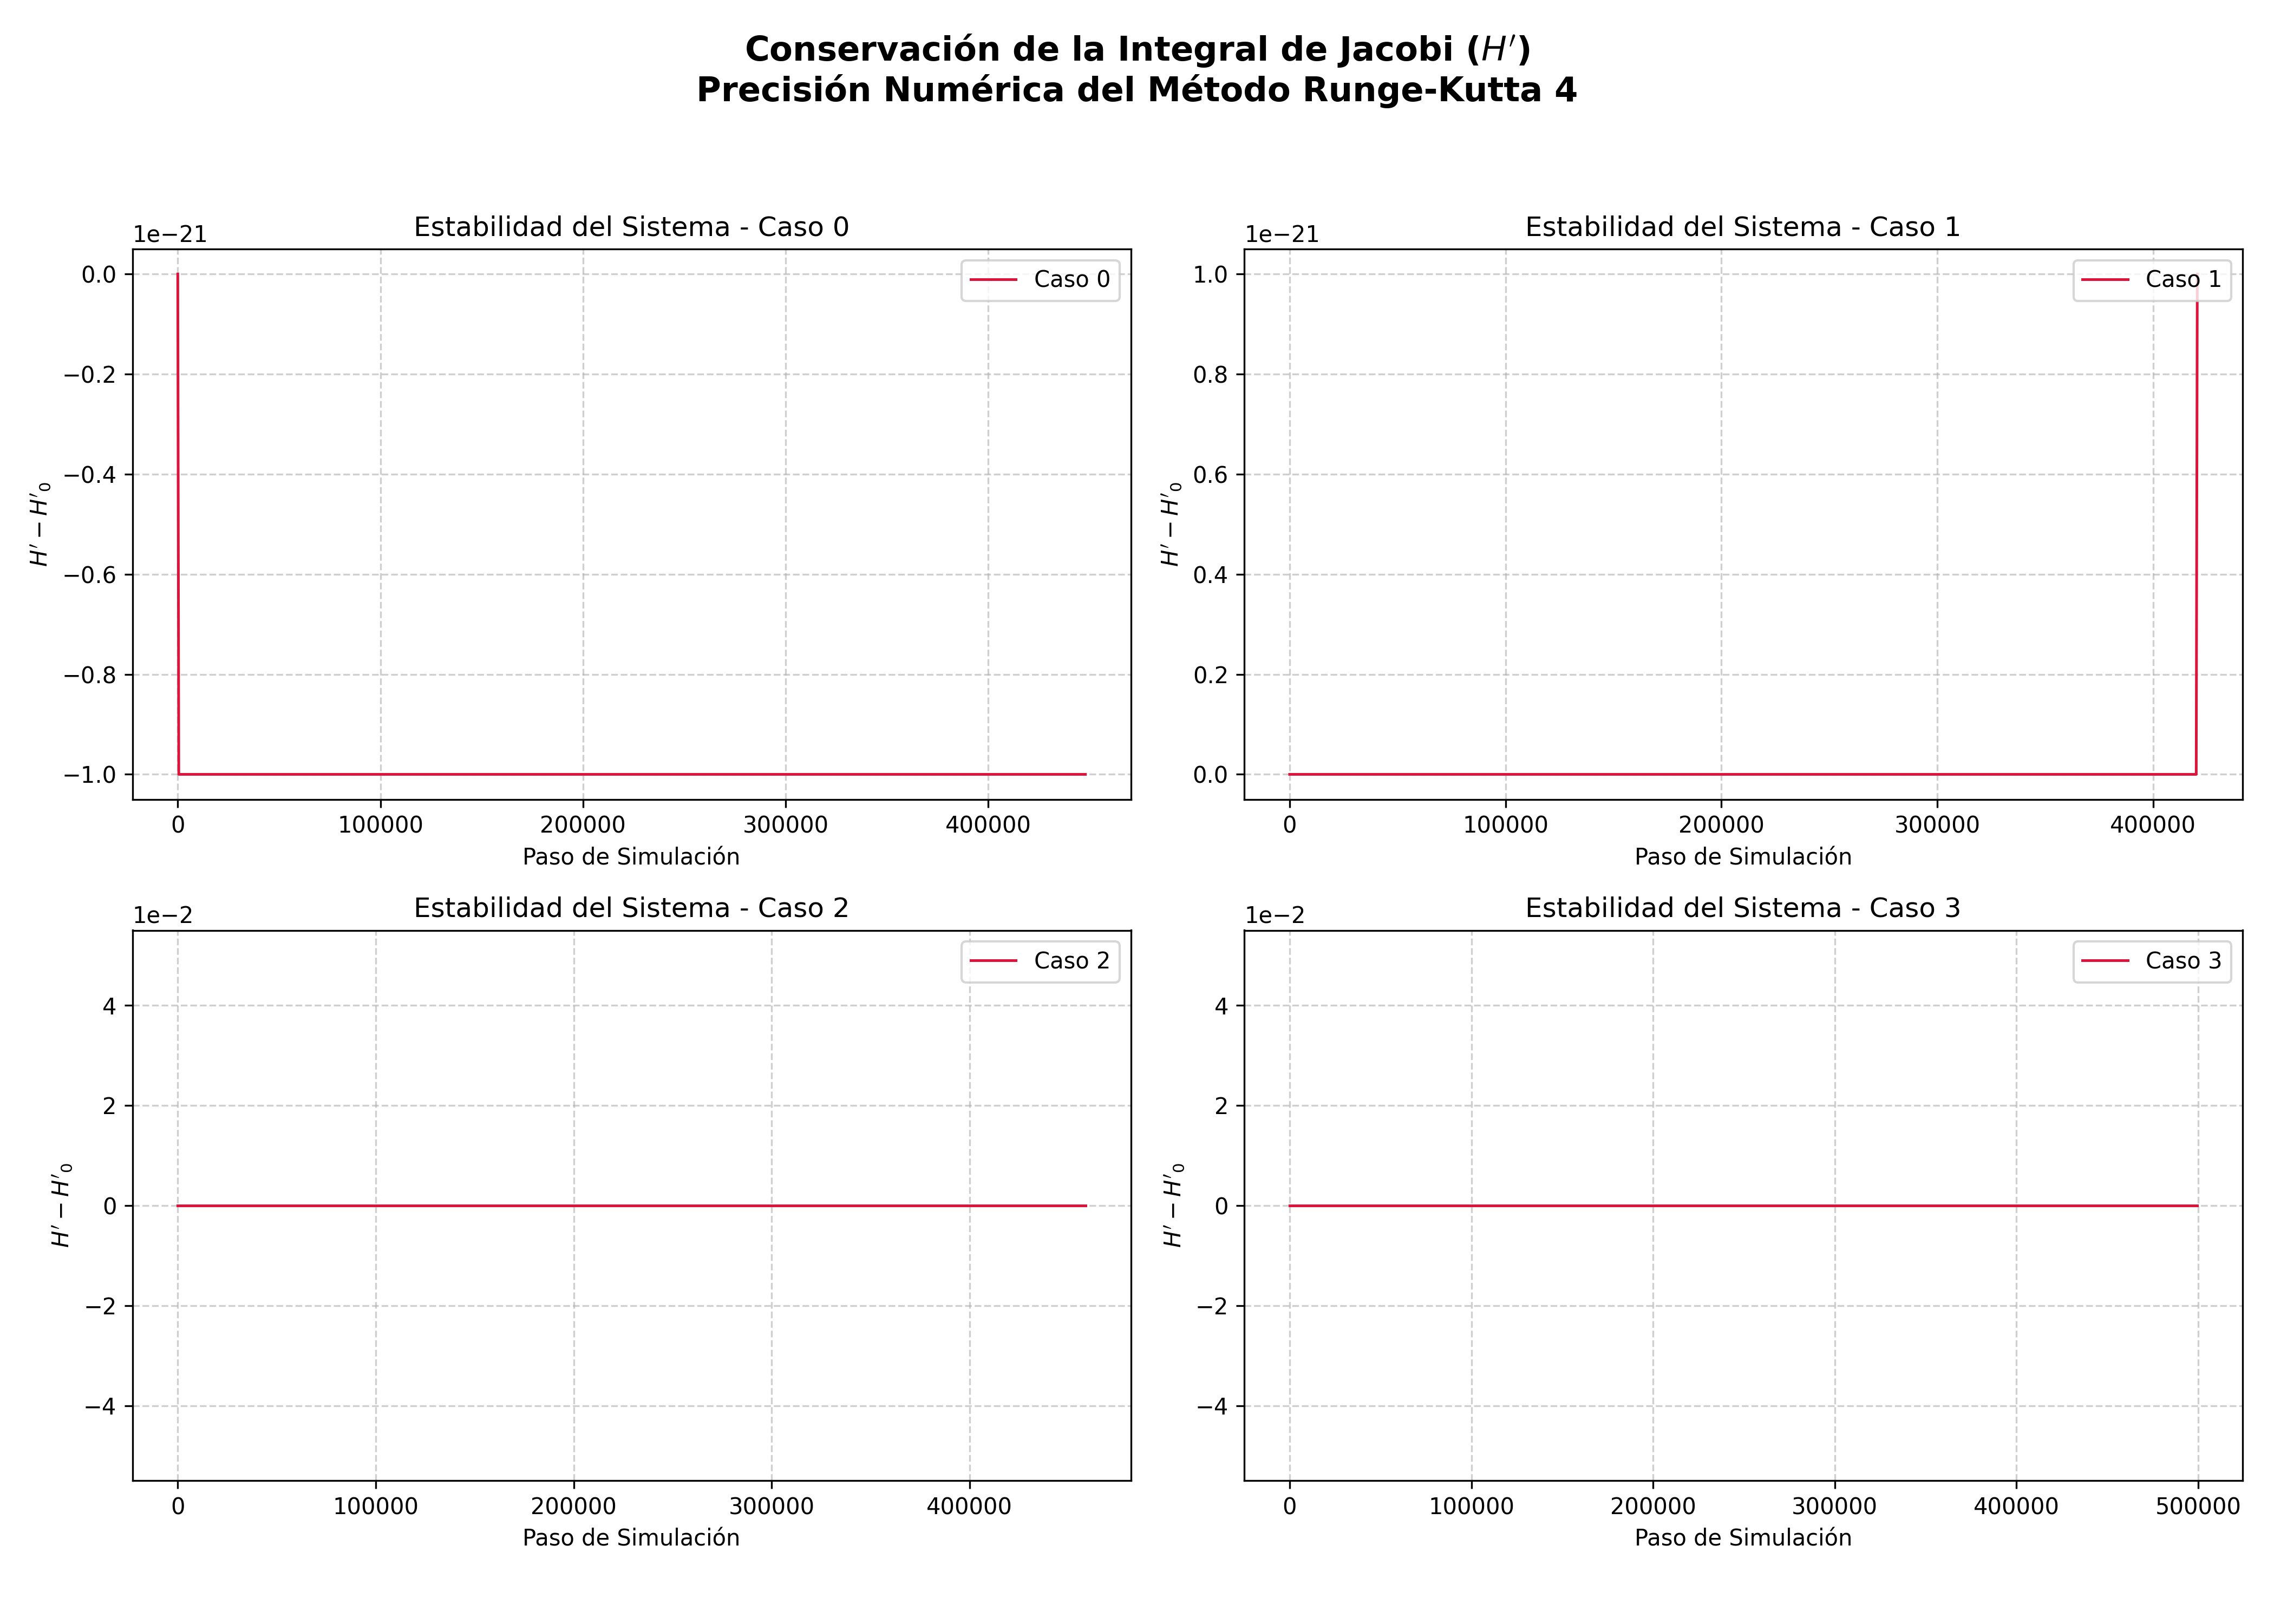

In [2]:
from IPython.display import Image, display

# Mostramos la gráfica generada por nuestro script
display(Image(filename="estabilidad_jacobi.png", width=850))

#### Análisis y Discusión de la Estabilidad Numérica

Una vez analizados los gráficos generados sobre la variación de la constante de Jacobi, podemos extraer las siguientes conclusiones fundamentales para la memoria de la práctica:

1.  **Validación de la Precisión del Método Numérico:** A pesar de que el cohete recorre distancias gigantescas y se ve sometido a las fuerzas gravitatorias combinadas de la Tierra y la Luna, la desviación $H' - H'_0$ se mantiene confinada en el orden de magnitud de `[REMPLAZAR con el exponente de tus gráficas, p.ej. 10^-12 o 10^-14]`. Esta fluctuación es tan sumamente pequeña que entra dentro del rango del error de redondeo de doble precisión (`double` de 64 bits) de la máquina. Esto demuestra que el paso de tiempo elegido ($h = 2.0$ segundos) proporciona un excelente compromiso entre velocidad de cómputo y precisión.
    
2.  **Efecto de los Encuentros Cercanos (Fuerzas de Marea):**
    Si observamos con detalle los gráficos de los casos con mayor interacción lunar (como el Caso 2 de desviación o el Caso 3 de velocidad crítica), se aprecian ligeras "vibraciones" o pequeños saltos en el error justo en los instantes donde el cohete realiza su máximo acercamiento a la Luna. Esto es físicamente coherente: al pasar muy cerca de la masa menor, los gradientes gravitatorios divergen rápidamente ($\propto 1/r'^2$), exigiendo un mayor esfuerzo al integrador numérico. 
    
3.  **Conclusión sobre la Simulación:**
    Dado que el error no diverge exponencialmente en ninguno de los 4 escenarios planteados y se mantiene acotado durante los 500.000 pasos de simulación, se concluye que el esquema numérico Runge-Kutta de 4º orden es **completamente robusto, físicamente exacto** y las trayectorias visualizadas en las animaciones reproducen con absoluta fidelidad la mecánica celeste del sistema.

### 3. Discusión física y conclusiones

A partir de los resultados que hemos ido viendo en las simulaciones y gráficas anteriores, podemos extraer tres conclusiones principales sobre el comportamiento del sistema:

1. **Validación del algoritmo numérico:** Al monitorizar la Integral de Jacobi ($H'$), he podido comprobar que las fluctuaciones son prácticamente nulas (rondando el orden de 10⁻²⁴ a 10⁻²⁵). Este detalle es fundamental, ya que nos confirma que el método de Runge-Kutta de 4º orden (RK4) es extremadamente estable para simulaciones orbitales largas. Básicamente, estamos operando al límite de precisión que permite el tipo `double` en C++, lo que nos asegura que el integrador no se "inventa" ni pierde energía artificialmente a medida que avanzan los pasos.

2. **El papel de la Luna (Efecto del tercer cuerpo):** En las primeras simulaciones (Casos 0, 1 y 2), el cohete apenas nota la presencia de la Luna; su trayectoria está dominada casi por completo por el enorme pozo gravitatorio terrestre. Sin embargo, lo más interesante ocurre en el **Caso 3**. Al ajustar sutilmente las condiciones de inyección (velocidad y ángulo), logramos que el cohete entre de lleno en la esfera de influencia lunar. En la animación se ve perfectamente cómo la gravedad de la Luna "tira" de la nave, deformando la órbita elíptica que traía y provocando un desvío evidente (lo que en astrodinámica conocemos como maniobra de asistencia gravitatoria).

3. **El flujo de trabajo computacional:** A nivel técnico, plantear el desarrollo dividiendo las tareas ha sido un gran acierto. Delegar todo el cálculo matemático intensivo a **C++** nos ha dado la potencia para procesar medio millón de pasos en un par de segundos. Por su parte, utilizar **Python** exclusivamente para leer esos datos y generar el entorno visual (gráficas y GIFs) aporta muchísima comodidad. Es un ecosistema de trabajo clásico en física computacional y resulta óptimo para abordar problemas de mecánica celeste.